# Texas Salary Prediction

## Business Case: To predict  the Salary of Texas' employees with given features

### Task 1:-Prepare a complete data analysis report on the given data.

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# loading the data
data=pd.read_csv('salary_data.csv')

C:\Users\Hello\AppData\Local\Temp\ipykernel_10812\2702641069.py:2: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('salary_data.csv')


In [4]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [5]:
data.tail()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN
149480,809,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,...,11.74,20.0,1017.46,12209.52,103583,NaN,NaN,NaN,NaN,NaN


In [6]:
pd.set_option("display.max_columns",None)
data

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


# Domain Analysis

1. AGENCY : A business or organization providing a particular service on behalf of another business, person, or group.

2. AGENCY NAME : A person or thing through which power is used or something is achieved

3. LAST NAME : It is the last name of the individual record.

4. FIRST NAME : It is the first name of the individual record.

5. MI : Middle initial.

6. CLASS CODE : These codes must be established before employees can be added to the system and payrolls processed.

7. CLASS TITLE : The official title used for all personnel and payroll processes.

8. ETHNICITY : The quality or fact of belonging to a population group or subgroup made up of people who share a common cultural background or descent.

9. GENDER : Is the range of characteristics pertaining to femininity and masculinity and differentiating between them.

10. STATUS : Position or rank in relation to others.

11. EMPLOYEE DATE : Date of joining of an individual.

12. HRLY RATE : The amount of money that is charged, paid, or earned for every hour worked.

13. HRS PER WEEK : The number of hours in a week that the employee normally would work for the shared work employer or 40 hours.

14. MONTHLY : A salary is the money that someone is paid each month by their employer.

15. ANNUAL : An annual salary is the total amount of money you earn from a job in a year.

16. STATE NUMBER : A unique number assigned to a business or organization by the state where the business operates, and is used for filing taxes and hiring employees.

17. DUPLICATED : One of two or more identical things.

18. MUTIPLE FULL TIME JOBS : Individuals works on one or more jobs in full time.

19. COMBINED MULTIPLE JOBS : The Combine Jobs feature allows you to merge two or more jobs from the same market view into a single job.

20. SUMMED ANNUAL SALARY : Total salary earned by an individual in a year including mutiple full time jobs and combined multiple jobs.

21. HIDE FROM SEARCH : Gives you the option for your web searches to be hidden with respect to organisation.

# Basic Checks

In [7]:
data.shape

(149481, 21)

In [8]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [9]:
data.tail()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN
149480,809,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,02/16/12,11.74,20.0,1017.46,12209.52,103583,NaN,NaN,NaN,NaN,NaN


In [10]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [11]:
data.dtypes

AGENCY                       int64
AGENCY NAME                 object
LAST NAME                   object
FIRST NAME                  object
MI                          object
CLASS CODE                  object
CLASS TITLE                 object
ETHNICITY                   object
GENDER                      object
STATUS                      object
EMPLOY DATE                 object
HRLY RATE                  float64
HRS PER WK                 float64
MONTHLY                    float64
ANNUAL                     float64
STATE NUMBER                 int64
duplicated                  object
multiple_full_time_jobs    float64
combined_multiple_jobs      object
summed_annual_salary       float64
hide_from_search            object
dtype: object

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [13]:
data.isnull().sum()

AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

In [14]:
data.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


##### Multiple full time jobs is having zero standard deviation hence it is a constant feature so it cannot affect target variable

# Exploratory Data Analysis

In [15]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [16]:
data.rename({'AGENCY NAME': 'AGENCY_NAME', 'CLASS CODE': 'CLASS_CODE','CLASS TITLE':'CLASS_TITLE','EMPLOY DATE':'EMPLOY_DATE','HRLY RATE':'HRLY_RATE','HRS PER WK':'HRS_PER_WK','STATE NUMBER':'STATE_NUMBER'}, axis=1,inplace=True)
     

In [17]:
data

,AGENCY,AGENCY_NAME,LAST NAME,FIRST NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


In [18]:
new_data=data[['AGENCY_NAME','CLASS_TITLE','ETHNICITY','GENDER','STATUS','HRLY_RATE','HRS_PER_WK','MONTHLY','STATE_NUMBER']]
new_data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,HRLY_RATE,HRS_PER_WK,MONTHLY,STATE_NUMBER
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,9545.82,127717
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,1404.77,127717
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,9545.82,59115
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,1404.77,59115
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,3284.27,165030
...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,2899.00,770781
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,5500.00,847431
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.93000,20.0,1120.60,34266
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,5744.16,123490


# UNIVARIATE ANALYSIS

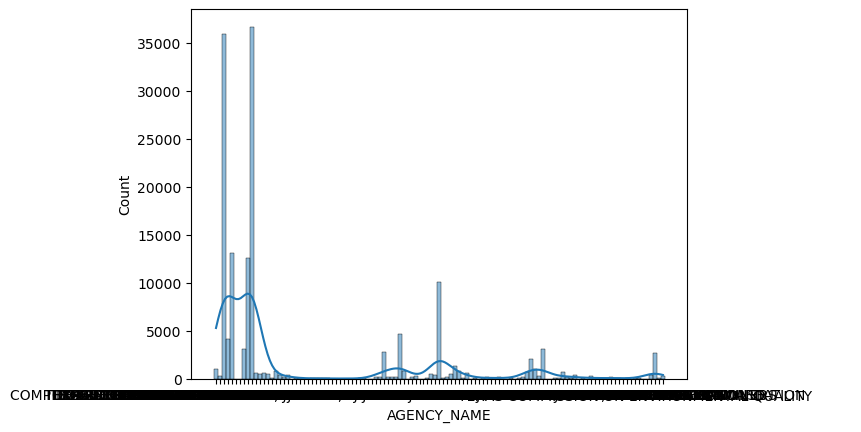

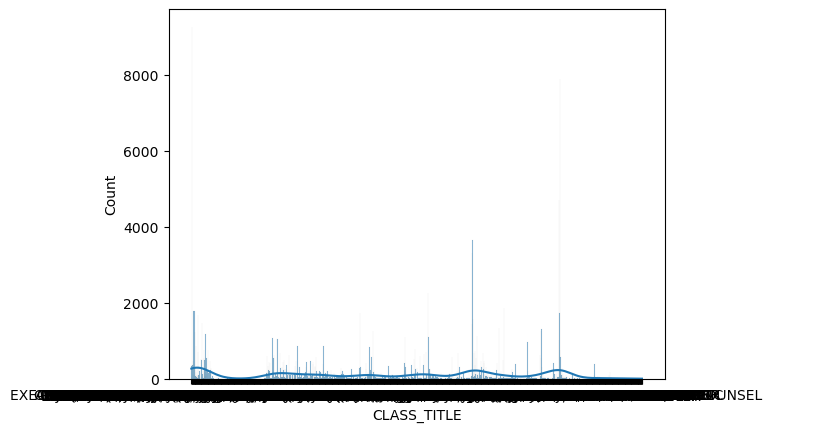

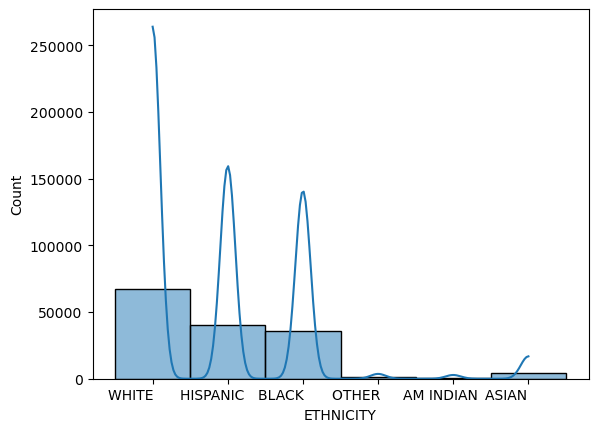

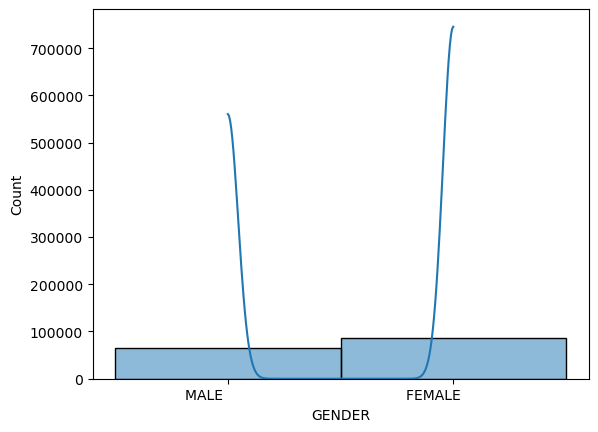

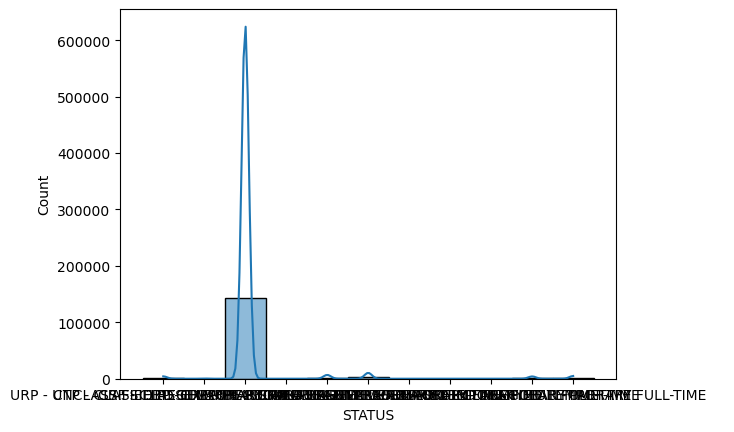

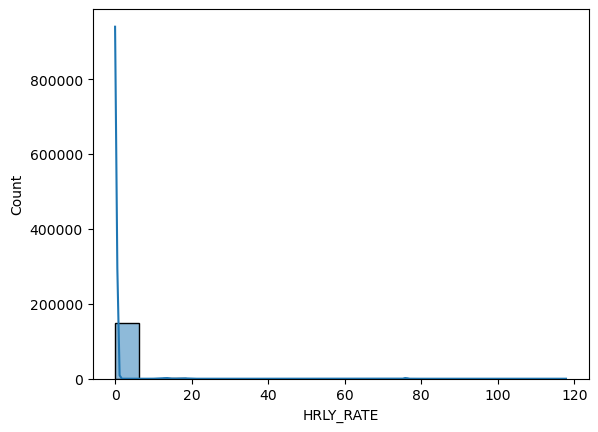

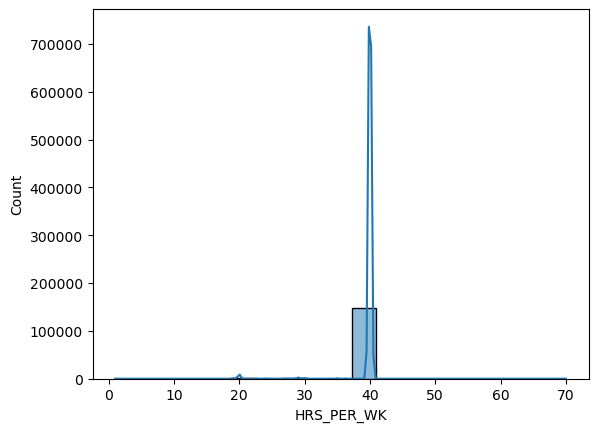

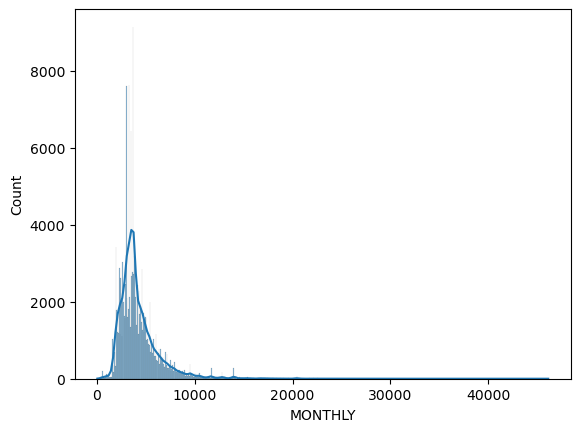

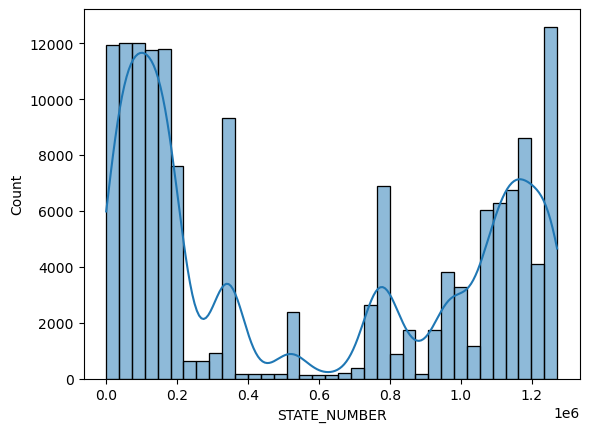

In [22]:
for columns in new_data:
  sns.histplot(x=columns, data=new_data,kde=True)
  plt.show()

1.There is no much variations in AGENCY_NAME AND CLASS_TITLE(no proper distribution).

2.More employees belongs to WHITE people.

3.More employees are FEMALE individuals.

4.Status and HRS_PER_WEEK is having normal distribution.

5.HRLY_RATE and MONTHLY is having left skewed distribution.

6.The majority of an employee is less than 10000 dollars per month.

7.The majority of employees works in CLASSIFIED_REGULAR_FULL_TIME.

8.The majority of employee working in HEALTH AND HUMAN SERVICES COMMISSION that is about 36667 and TEXAS DEPARTMENT OF CRIMINAL JUSTICE is being in second place having 35926.

9.The majority no. of employees earn on a range of 0-8 dollars per hour.

10.The majority no.of employees work on an avearge of 40 hours per week.

# BIVARIATE ANALYSIS

#### It refers to plots between input variables and target variable

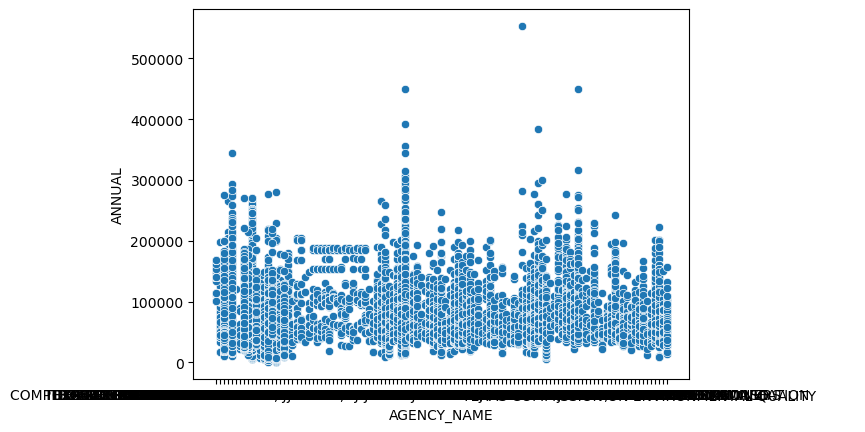

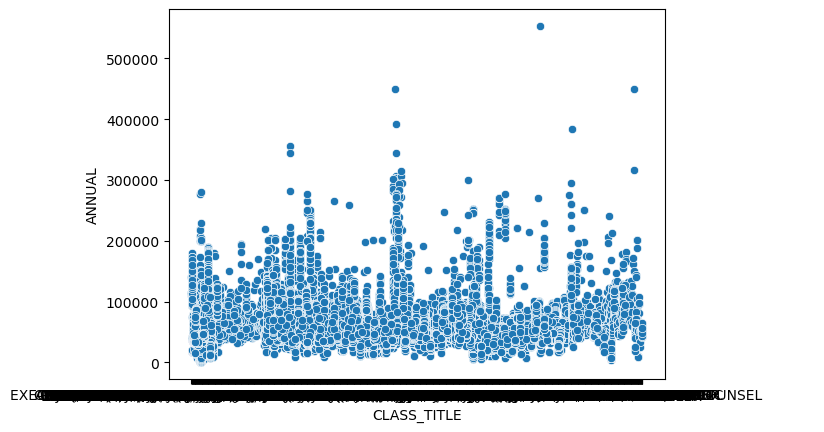

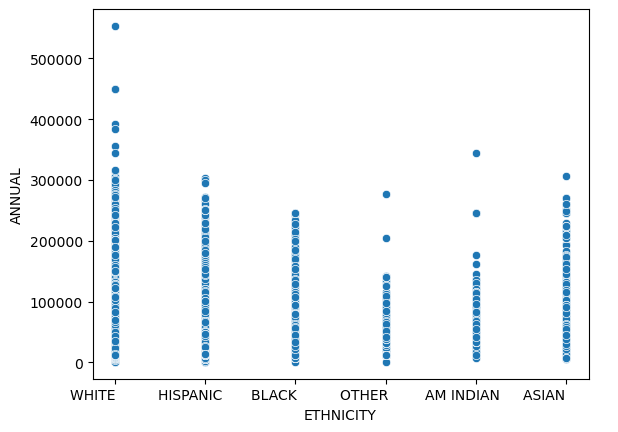

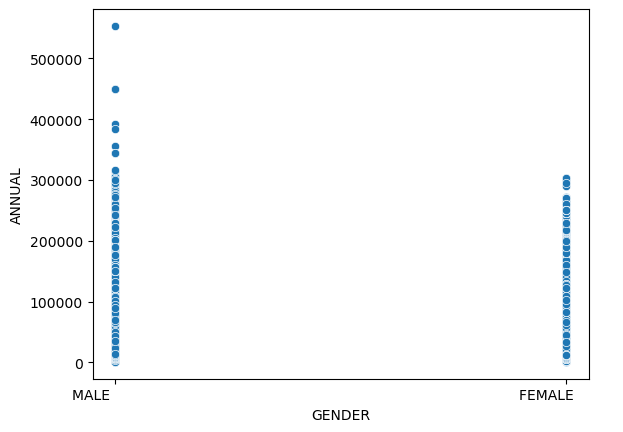

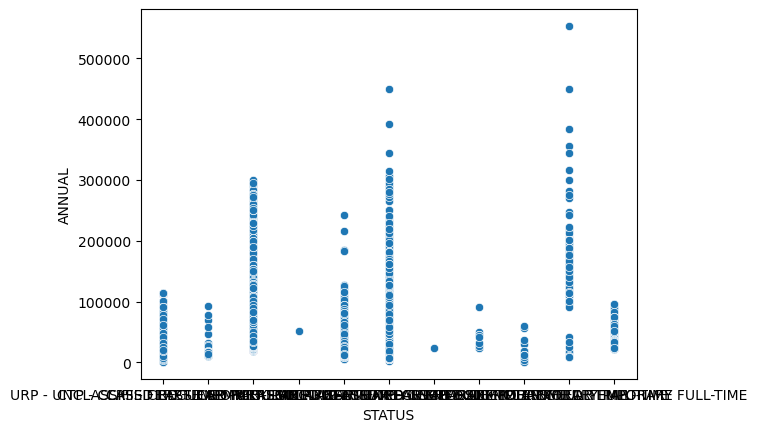

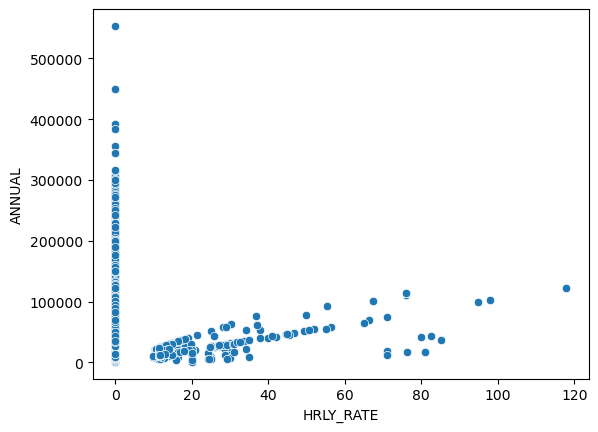

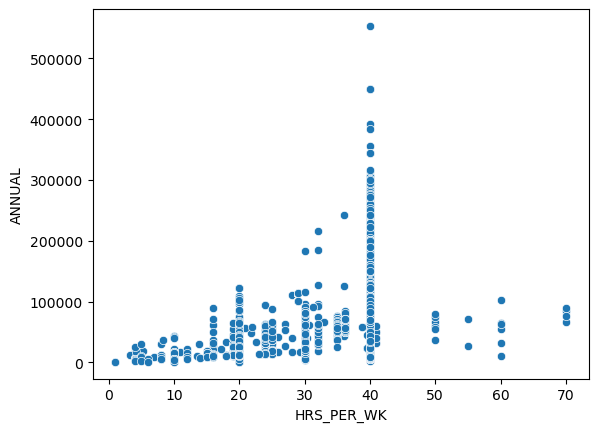

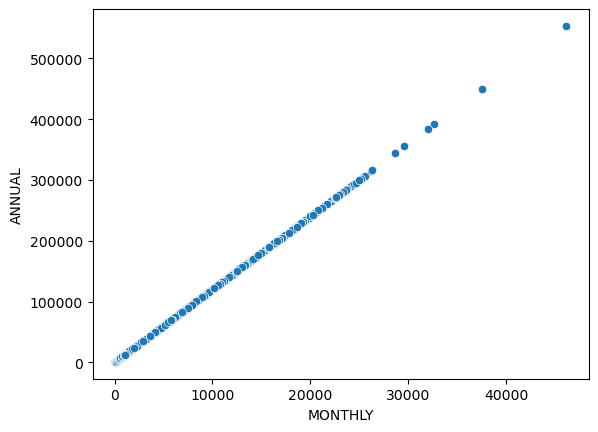

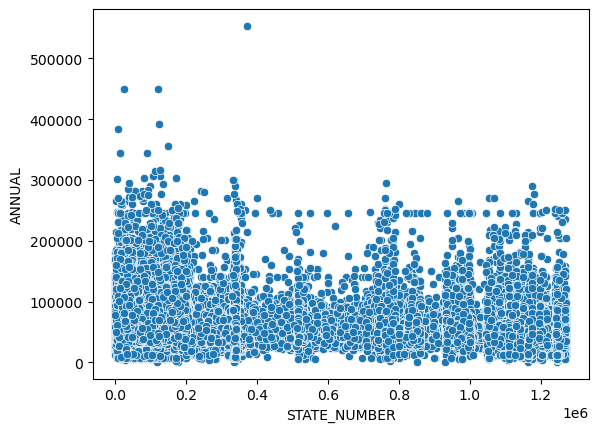

In [23]:
for columns in new_data:
  sns.scatterplot(x=columns,y=data.ANNUAL,data=new_data)
  plt.show()

In [34]:
data.loc[data['ANNUAL'] == 553500]

,AGENCY,AGENCY_NAME,LAST NAME,FIRST NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,03-01-2016,0.0,40.0,46125.0,553500.0,372291,NaN,NaN,NaN,NaN,NaN


In [24]:
data.loc[data['ANNUAL'] > 400000]

,AGENCY,AGENCY_NAME,LAST NAME,FIRST NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
14793,323,TEACHER RETIREMENT SYSTEM ...,AUBY,JASE,R,C204,CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,11-09-2009,0.0,40.0,37500.0,450000.0,121522,NaN,NaN,NaN,NaN,NaN
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,03-01-2016,0.0,40.0,46125.0,553500.0,372291,NaN,NaN,NaN,NaN,NaN
144232,327,EMPLOYEES RETIREMENT SYSTEM ...,TULL,CHARLES,T,D136,DIRECTOR OF INVESTMENTS ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,02-01-2009,0.0,40.0,37500.0,450000.0,24680,NaN,NaN,NaN,NaN,NaN


1.There is no trend between AGENCY_NAME and ANNUAL.

2.There is no trend between CLASS_TITLE and ANNUAL.

3.The Agencies are paying less than 200000$ to their majority of employees per year.

4.The Chief Scientific Officer is getting highest salary that is about 553500$ per Annum.

5.In Class_title majority of designation individual getting less then 200000$.

6.Excluding WHITE peoples others are getting less than 300000$ per annum.

7.The highest salary paid to WHITE people is about 500000$ per annum.

8.Male individuals are getting more salary compared to Female individuals.

9.The maximum salaries are earned by UNCLASSIFIED REGULAR FULL-TIME and EXEMPT REGULAR FULL-TIME.

10.The people who are working 30-40 HRS_PER_WEEK are getting higher salaries compared to others.

11.HRLY_RATE and MONTHLY is having linear trend with annual.

12.The females are getting paid less than 3lakh dollars.

13.Only one employee of STATE_NUMBER(372291) has salary of above 5lakh dollars and majority of them have salary less tham 3lakh dollars annually.

In [25]:
data

,AGENCY,AGENCY_NAME,LAST NAME,FIRST NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


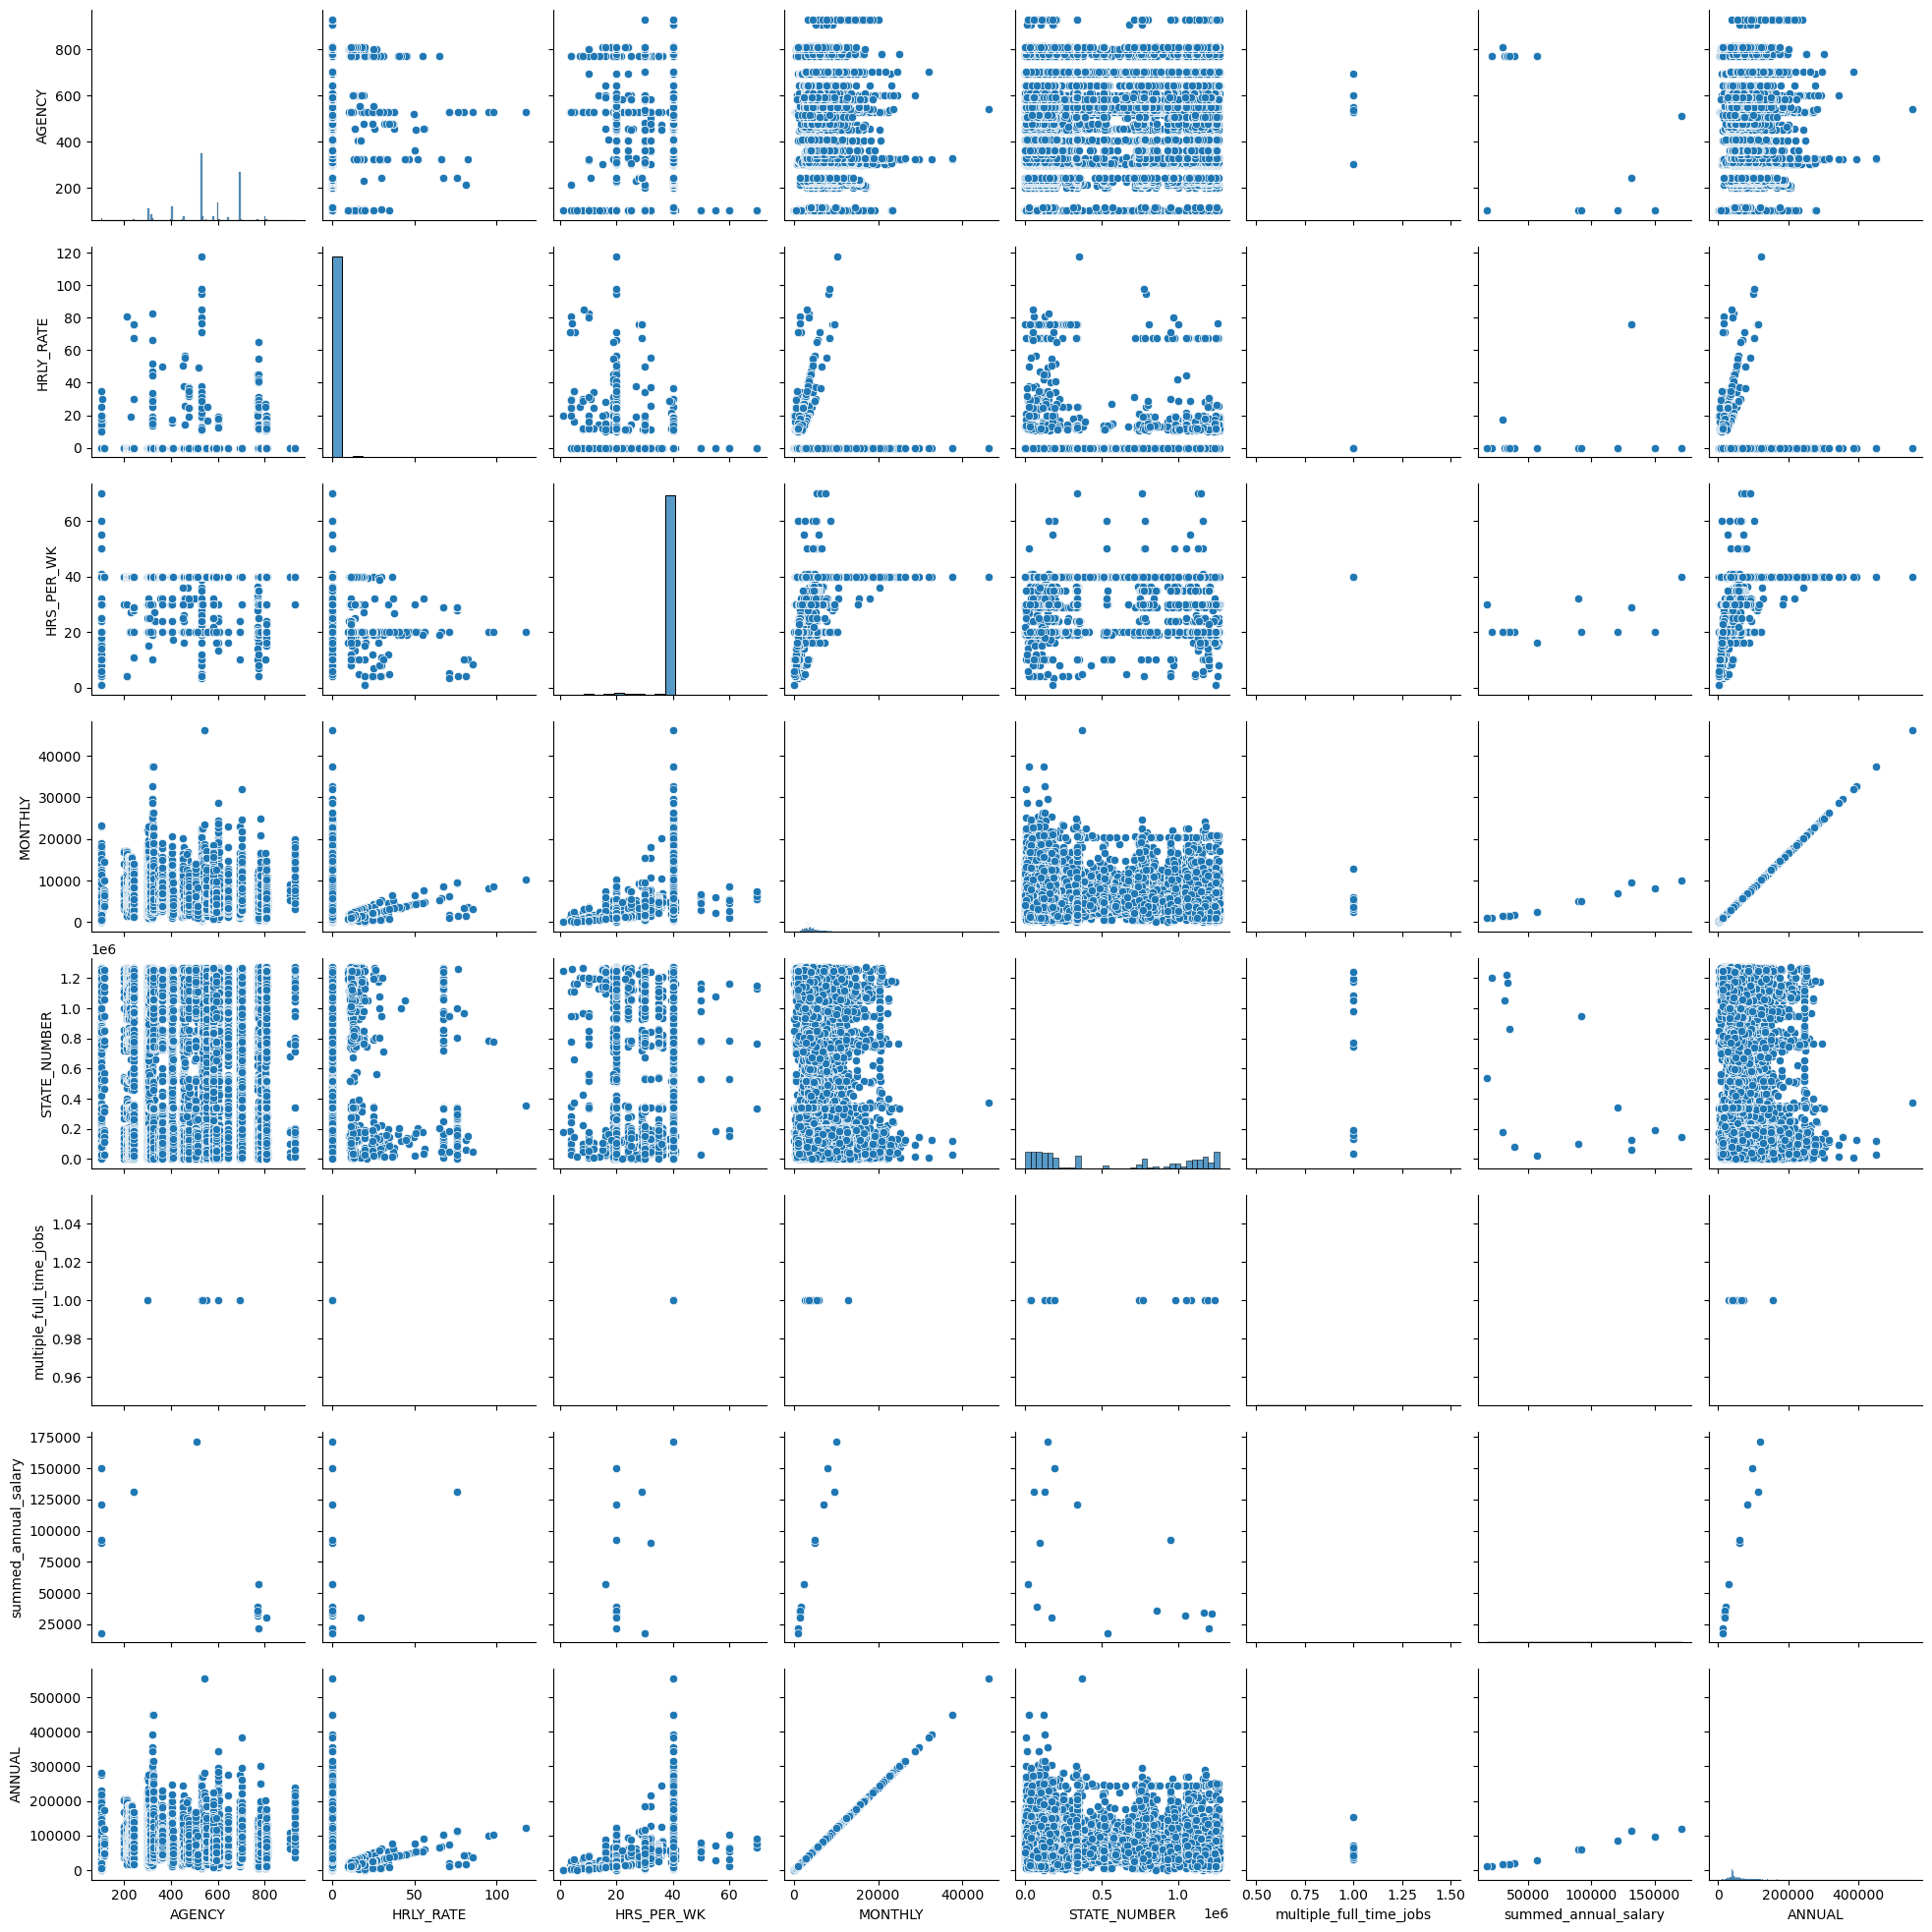

In [26]:
sns.pairplot(data=data[['AGENCY','HRLY_RATE','HRS_PER_WK','MONTHLY','STATE_NUMBER','multiple_full_time_jobs','summed_annual_salary','ANNUAL']])
plt.show()

# MULTIVARIATE ANALYSIS

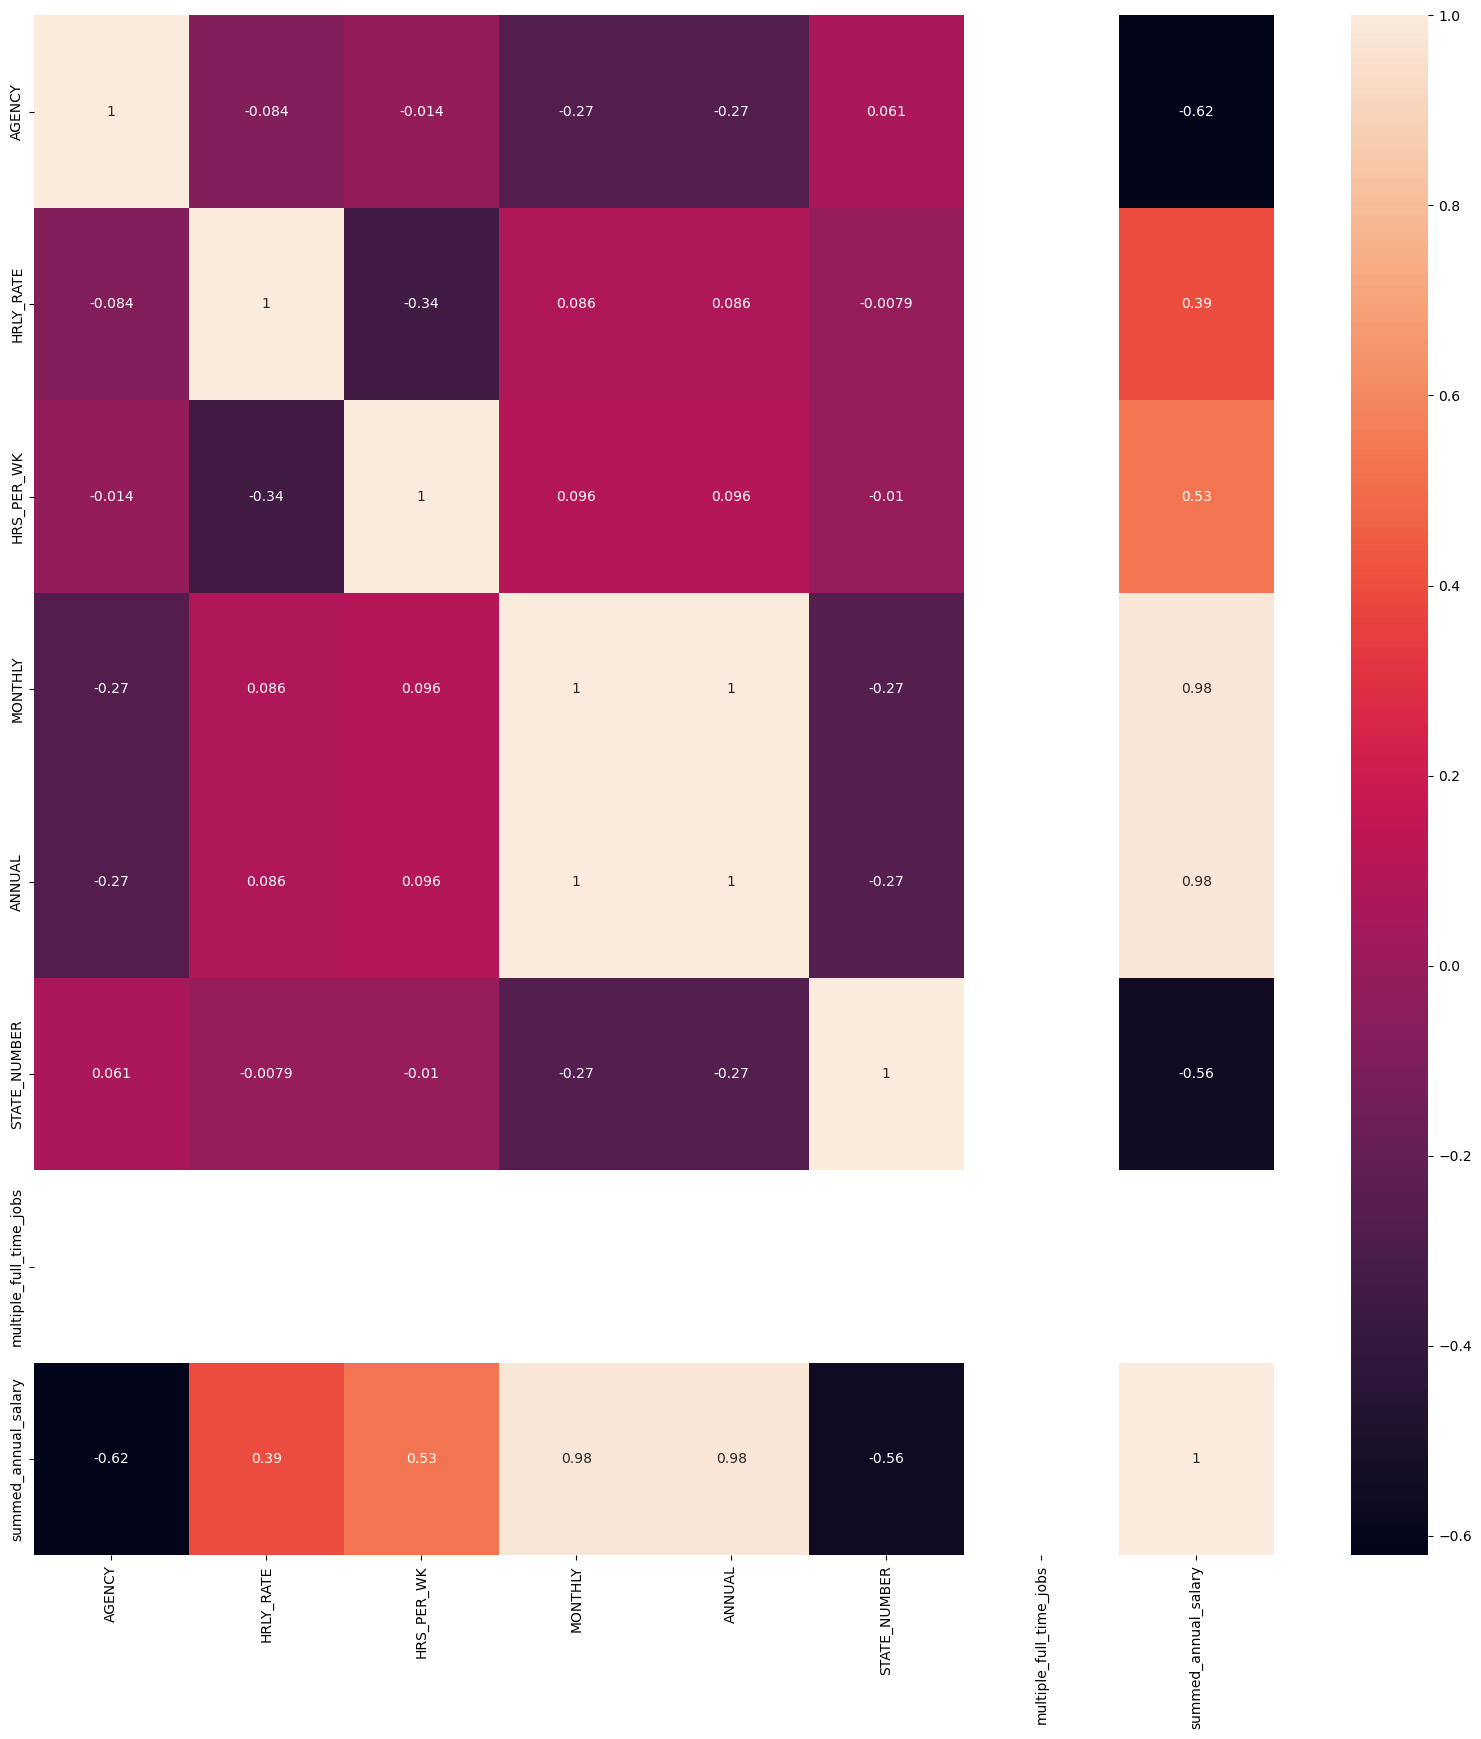

In [28]:
# Filter only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(20,20), facecolor='white')
sns.heatmap(data=numeric_data.corr(), annot=True)
plt.show()

1. Monthly is having **0.98 **correlation with summed_annual_salary, so both columns are highly co related with each other.

2. Multiple_full_time_jobs is highly correlated with every other feature.

3. MONTHLY and ANNUAL columns are highly correlated with each other i.e, 100% so we are dropping MONTHLY columns.

# Data Preprocessing and Feature Engineering

Handling missing values

In [29]:
data.isnull().sum()

AGENCY                          0
AGENCY_NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS_CODE                      0
CLASS_TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY_DATE                     0
HRLY_RATE                       0
HRS_PER_WK                      0
MONTHLY                         0
ANNUAL                          0
STATE_NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

1. As, last five columns have more than 95% of them are null values,we will ignore them.

2. For particular AGENCY code there is unique AGENCY_NAME so, we are dropping AGENCY.

3. We are droping LAST NAME,FIRST NAME,MI since there is no relation with target variable.

4. For particular CLASS_TITLE there is unique CLASS_CODE so, we are dropping CLASS_CODE.

In [30]:
data.columns

Index(['AGENCY', 'AGENCY_NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS_CODE',
       'CLASS_TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY_DATE',
       'HRLY_RATE', 'HRS_PER_WK', 'MONTHLY', 'ANNUAL', 'STATE_NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [31]:
data=data.drop(['AGENCY','LAST NAME','FIRST NAME','MI','CLASS_CODE','duplicated','MONTHLY','multiple_full_time_jobs','combined_multiple_jobs','summed_annual_salary','hide_from_search'],axis=1)

In [32]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,114549.84,127717
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,16857.24,127717
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,114549.84,59115
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,16857.24,59115
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,39411.24,165030
...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,34788.00,770781
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,66000.00,847431
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,13447.20,34266
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,68929.92,123490


### HANDLING EMPLOY_DATE COLUMN

In [33]:
#  Converting object dtype date to datetime dtype
from datetime import datetime as dt
data['EMPLOY_DATE'] = pd.to_datetime(data['EMPLOY_DATE'])
# add a column for Year
data['Year'] = data['EMPLOY_DATE'].dt.year

C:\Users\Hello\AppData\Local\Temp\ipykernel_10812\1808795648.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['EMPLOY_DATE'] = pd.to_datetime(data['EMPLOY_DATE'])


In [34]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,Year
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.96150,29.0,114549.84,127717,1988
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2015-02-01,81.04454,4.0,16857.24,127717,2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.96150,29.0,114549.84,59115,2020
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2018-09-01,81.04453,4.0,16857.24,59115,2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-06-29,0.00000,40.0,39411.24,165030,2020
...,...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2017-10-30,0.00000,40.0,34788.00,770781,2017
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2015-07-13,0.00000,40.0,66000.00,847431,2015
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,2012-10-15,12.93000,20.0,13447.20,34266,2012
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,1989-09-22,0.00000,40.0,68929.92,123490,1989


In [35]:
# Fetching today's date and removing time stamp(converting time to zeros)
import datetime as dt
data['cur_yr']=dt.datetime.combine(dt.date.today(), dt.datetime.min.time())

In [36]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,Year,cur_yr
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.96150,29.0,114549.84,127717,1988,2025-12-10
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2015-02-01,81.04454,4.0,16857.24,127717,2015,2025-12-10
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.96150,29.0,114549.84,59115,2020,2025-12-10
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2018-09-01,81.04453,4.0,16857.24,59115,2018,2025-12-10
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-06-29,0.00000,40.0,39411.24,165030,2020,2025-12-10
...,...,...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2017-10-30,0.00000,40.0,34788.00,770781,2017,2025-12-10
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2015-07-13,0.00000,40.0,66000.00,847431,2015,2025-12-10
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,2012-10-15,12.93000,20.0,13447.20,34266,2012,2025-12-10
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,1989-09-22,0.00000,40.0,68929.92,123490,1989,2025-12-10


#### We are subtracting Current year with EMPLOY_DATE and applying it to lambda function to calculate years for each record.

In [37]:
data['yrs']=((data.cur_yr)-(data.EMPLOY_DATE)).apply(lambda x: str(x).split(' ')[0]).apply(lambda x: int(x)/365)

In [38]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,Year,cur_yr,yrs
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.96150,29.0,114549.84,127717,1988,2025-12-10,37.835616
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2015-02-01,81.04454,4.0,16857.24,127717,2015,2025-12-10,10.863014
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.96150,29.0,114549.84,59115,2020,2025-12-10,5.860274
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2018-09-01,81.04453,4.0,16857.24,59115,2018,2025-12-10,7.279452
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-06-29,0.00000,40.0,39411.24,165030,2020,2025-12-10,5.452055
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2017-10-30,0.00000,40.0,34788.00,770781,2017,2025-12-10,8.117808
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2015-07-13,0.00000,40.0,66000.00,847431,2015,2025-12-10,10.419178
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,2012-10-15,12.93000,20.0,13447.20,34266,2012,2025-12-10,13.161644
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,1989-09-22,0.00000,40.0,68929.92,123490,1989,2025-12-10,36.241096


In [39]:
data.yrs.max()

57.06301369863014

In [40]:
data.yrs.min()

-43.62191780821918

In [41]:
neg= data.loc[data['yrs']<0]
neg

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,Year,cur_yr,yrs
116978,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,AGRICULTURE SPEC V ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2069-07-14,0.0,40.0,48404.88,68427,2069,2025-12-10,-43.621918
141891,HOUSE OF REPRESENTATIVES ...,ELECTED OFFICIAL ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2069-01-14,0.0,40.0,7200.00,116511,2069,2025-12-10,-43.126027


In [42]:
# The joining date of employee is higher than the Current Date which leads to negative years of experience so, we are dropping those 5 records.
data.drop(neg.index,inplace=True)

In [43]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,Year,cur_yr,yrs
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.96150,29.0,114549.84,127717,1988,2025-12-10,37.835616
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2015-02-01,81.04454,4.0,16857.24,127717,2015,2025-12-10,10.863014
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.96150,29.0,114549.84,59115,2020,2025-12-10,5.860274
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,2018-09-01,81.04453,4.0,16857.24,59115,2018,2025-12-10,7.279452
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-06-29,0.00000,40.0,39411.24,165030,2020,2025-12-10,5.452055
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2017-10-30,0.00000,40.0,34788.00,770781,2017,2025-12-10,8.117808
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2015-07-13,0.00000,40.0,66000.00,847431,2015,2025-12-10,10.419178
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,2012-10-15,12.93000,20.0,13447.20,34266,2012,2025-12-10,13.161644
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,1989-09-22,0.00000,40.0,68929.92,123490,1989,2025-12-10,36.241096


In [44]:
data.shape

(149479, 13)

In [45]:
data.columns

Index(['AGENCY_NAME', 'CLASS_TITLE', 'ETHNICITY', 'GENDER', 'STATUS',
       'EMPLOY_DATE', 'HRLY_RATE', 'HRS_PER_WK', 'ANNUAL', 'STATE_NUMBER',
       'Year', 'cur_yr', 'yrs'],
      dtype='object')

In [46]:
data.drop(['EMPLOY_DATE','Year','cur_yr'],inplace=True,axis=1)

In [48]:
data

,AGENCY_NAME,CLASS_TITLE,ETHNICITY,GENDER,STATUS,HRLY_RATE,HRS_PER_WK,ANNUAL,STATE_NUMBER,yrs
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,127717,37.835616
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,16857.24,127717,10.863014
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,59115,5.860274
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,16857.24,59115,7.279452
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,39411.24,165030,5.452055
...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,34788.00,770781,8.117808
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,66000.00,847431,10.419178
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.93000,20.0,13447.20,34266,13.161644
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,68929.92,123490,36.241096


## CATEGORICAL ENCODING - ONE HOT ENCODING

In [49]:
data=pd.get_dummies(data,drop_first= False)
data

HRLY_RATE  HRS_PER_WK     ANNUAL  STATE_NUMBER        yrs  \
0        75.96150        29.0  114549.84        127717  37.835616   
1        81.04454         4.0   16857.24        127717  10.863014   
2        75.96150        29.0  114549.84         59115   5.860274   
3        81.04453         4.0   16857.24         59115   7.279452   
4         0.00000        40.0   39411.24        165030   5.452055   
...           ...         ...        ...           ...        ...   
149476    0.00000        40.0   34788.00        770781   8.117808   
149477    0.00000        40.0   66000.00        847431  10.419178   
149478   12.93000        20.0   13447.20         34266  13.161644   
149479    0.00000        40.0   68929.92        123490  36.241096   
149480   11.74000        20.0   12209.52        103583  13.824658   

        AGENCY_NAME_ALCOHOLIC BEVERAGE COMMISSION                       \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF ARCHITECTURAL EXAMINERS                    \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF CHIROPRACTIC EXAMINERS                     \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF DENTAL EXAMINERS                           \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...           

In [50]:
data.shape

(149479, 1559)

# Scaling


Scaling the data is not required for the given dataset because we have only limited or very less variations in the feature columns.

## Task 2:-Create a predictive model which will help the Texas state government team to know the payroll information of employees of the state of Texas.

### Model Creation

In [51]:
X= data.drop(['ANNUAL'],axis=1)
y=data.ANNUAL

In [52]:
X

HRLY_RATE  HRS_PER_WK  STATE_NUMBER        yrs  \
0        75.96150        29.0        127717  37.835616   
1        81.04454         4.0        127717  10.863014   
2        75.96150        29.0         59115   5.860274   
3        81.04453         4.0         59115   7.279452   
4         0.00000        40.0        165030   5.452055   
...           ...         ...           ...        ...   
149476    0.00000        40.0        770781   8.117808   
149477    0.00000        40.0        847431  10.419178   
149478   12.93000        20.0         34266  13.161644   
149479    0.00000        40.0        123490  36.241096   
149480   11.74000        20.0        103583  13.824658   

        AGENCY_NAME_ALCOHOLIC BEVERAGE COMMISSION                       \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF ARCHITECTURAL EXAMINERS                    \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF CHIROPRACTIC EXAMINERS                     \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              False                
149478                                              False                
149479                                              False                
149480                                              False                

        AGENCY_NAME_BOARD OF DENTAL EXAMINERS                           \
0                                                   False                
1                                                   False                
2                                                   False                
3                                                   False                
4                                                   False                
...                                                   ...                
149476                                              False                
149477                                              

In [53]:
X.shape

(149479, 1558)

In [54]:
y.shape

(149479,)

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=33)

In [56]:
X_train

HRLY_RATE  HRS_PER_WK  STATE_NUMBER        yrs  \
138891        0.0        40.0       1183283   6.597260   
141180        0.0        40.0        170113  12.452055   
102589        0.0        40.0         25815   9.249315   
90879         0.0        40.0       1065918   8.698630   
77818         0.0        40.0        766830  11.263014   
...           ...         ...           ...        ...   
34877         0.0        40.0         91803   6.449315   
147560        0.0        40.0        194055  22.290411   
75971         0.0        40.0        188039  19.567123   
131651        0.0        40.0        126668  28.898630   
104152        0.0        20.0       1169100   6.832877   

        AGENCY_NAME_ALCOHOLIC BEVERAGE COMMISSION                       \
138891                                              False                
141180                                              False                
102589                                              False                
90879                                               False                
77818                                               False                
...                                                   ...                
34877                                               False                
147560                                              False                
75971                                               False                
131651                                              False                
104152                                              False                

        AGENCY_NAME_BOARD OF ARCHITECTURAL EXAMINERS                    \
138891                                              False                
141180                                              False                
102589                                              False                
90879                                               False                
77818                                               False                
...                                                   ...                
34877                                               False                
147560                                              False                
75971                                               False                
131651                                              False                
104152                                              False                

        AGENCY_NAME_BOARD OF CHIROPRACTIC EXAMINERS                     \
138891                                              False                
141180                                              False                
102589                                              False                
90879                                               False                
77818                                               False                
...                                                   ...                
34877                                               False                
147560                                              False                
75971                                               False                
131651                                              False                
104152                                              False                

        AGENCY_NAME_BOARD OF DENTAL EXAMINERS                           \
138891                                              False                
141180                                              False                
102589                                              False                
90879                                               False                
77818                                               False                
...                                                   ...                
34877                                               False                
147560                                              

## Linear Regression

In [57]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression() # object creation
LR.fit(X_train,y_train) # training of linear regression
y_predict=LR.predict(X_train) #y_predict is the model predicted output

In [58]:
y_train # Actual output values

138891    34022.76
141180    59232.00
102589    38390.40
90879     40560.00
77818     63746.64
            ...   
34877     27754.20
147560    62659.56
75971     34083.84
131651    44642.04
104152    19705.68
Name: ANNUAL, Length: 112109, dtype: float64

In [59]:
y_predict # Values predicted by model

array([33911.44604346, 58970.76733467, 39745.93437359, ...,
       34435.89986805, 46343.43130027, 17878.28635569])

In [61]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

r2score=r2_score(y_train,y_predict)

In [62]:
r2score

0.9514208596593321

In [63]:
X_test.shape

(37370, 1558)

In [64]:
## calculation of adjusted r2 score
adjusted_r2 = 1-(1-0.94)*(37369-1)/(37369-1558-1)
adjusted_r2

0.9373895559899469

## Decision Tree Regressor

In [65]:
from sklearn.tree import DecisionTreeRegressor #importing decision tree from sklearn.tree

model = DecisionTreeRegressor(random_state=44)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [66]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

r2score=r2_score(y_test,predictions)

In [67]:
r2score

0.8208200229499387

In [68]:
X_test.shape

(37370, 1558)

In [69]:
## calculation of adjusted r2 score
adjusted_r2 = 1-(1-0.836)*(37369-1)/(37369-1558-1)
adjusted_r2

0.8288647863725216

## Random Forest Regressor

In [71]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X_train, y_train) 

RandomForestRegressor(n_estimators=10, random_state=0)

In [72]:
predictions = model.predict(X_test)

In [73]:
y_predict=regressor.predict(X_test)

In [74]:
r2score=r2_score(y_test,y_predict)

In [75]:
r2score

0.8629044470479613

In [76]:
adjusted_r2 = 1-(1-0.875)*(37369-1)/(37369-1558-1)
adjusted_r2

0.8695615749790562

### For different n_estimators we got below r2score and adjusted_r2

1. n_estimators = 10, r2score = 0.87, adjusted_r2 = 0.86

2. n_estimators = 50, r2score = 0.884, adjusted_r2 = 0.878

3. n_estimators = 100, r2score = 0.885, adjusted_r2 = 0.879

So from the above data there is no much variation in r2score and adjusted_r2 for respective n_estimators, So we are considering n_estimators = 10, for training Random Forest Regressor model.

# KNN Regressor

In [77]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

error_rate = [] #create list to store rmse values for different k
for K in range(0,20):
    K = K+1
    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    error_rate.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 31953.26241499716
RMSE value for k=  2 is: 27992.72086730871
RMSE value for k=  3 is: 26486.591591359887
RMSE value for k=  4 is: 25827.727282293192
RMSE value for k=  5 is: 25387.79503434671
RMSE value for k=  6 is: 25100.80776126125
RMSE value for k=  7 is: 24875.111657651483
RMSE value for k=  8 is: 24724.396841550257
RMSE value for k=  9 is: 24587.442948231164
RMSE value for k=  10 is: 24488.43778216182
RMSE value for k=  11 is: 24413.462111572393
RMSE value for k=  12 is: 24366.081091388074
RMSE value for k=  13 is: 24295.287556122872
RMSE value for k=  14 is: 24241.52896515985
RMSE value for k=  15 is: 24207.36805561669
RMSE value for k=  16 is: 24161.942427192236
RMSE value for k=  17 is: 24147.377556462583
RMSE value for k=  18 is: 24110.157899494447
RMSE value for k=  19 is: 24084.41120628699
RMSE value for k=  20 is: 24064.51117272922


In [80]:
plt.figure(figsize=(10,6))
plt.plot(range(0,20),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

Text(0, 0.5, 'Error Rate')

In [82]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors = 8)
model.fit(X_train, y_train)  #fit the model
pred=model.predict(X_test)

In [83]:
r2score=r2_score(y_test,pred)

In [84]:
r2score

0.03148873790622697

In [85]:
adjusted_r2 = 1-(1-0.04)*(37369-1)/(37369-1558-1)
adjusted_r2

-0.001767104160848909

# Task 3:

### 1. Who are the outliers in the salaries?

#### DataFrame df contains the outliers of salaries.

In [88]:
# Reading data again.
data=pd.read_csv('salary_data.csv')

C:\Users\Hello\AppData\Local\Temp\ipykernel_10812\1069094962.py:2: DtypeWarning: Columns (16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('salary_data.csv')


In [91]:
sns.boxplot(x='ANNUAL',data=data)

<Axes: title={'center': 'Error Rate vs. K Value'}, xlabel='K', ylabel='Error Rate'>

In [92]:
from scipy import stats
IQR= stats.iqr(data.ANNUAL,interpolation='midpoint')
IQR

np.float64(22151.64)

In [93]:
Q1= data.ANNUAL.quantile(0.25)
Q3= data.ANNUAL.quantile(0.75)
print(Q1)
Q3

36238.08


np.float64(58389.72)

In [98]:
low_limit= Q1- 1.5*IQR
upp_limit= Q3+ 1.5*IQR
print(low_limit)
upp_limit

3010.6200000000026


np.float64(91617.18)

In [96]:
upper=data.loc[data['ANNUAL']>upp_limit]
upper

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.9615,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.9615,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
5,302,OFFICE OF THE ATTORNEY GENERAL ...,ROGERS,SHAUNA,,1623,DIRECTOR IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,04-01-2020,0.0000,40.0,12899.00,154788.00,1177785,True,1.0,NaN,NaN,NaN
7,510,TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL ...,SPINKS,DARREL,D,1623,DIRECTOR IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,03-01-2020,0.0000,40.0,10000.00,120000.00,147334,True,NaN,NaN,171383.40,NaN
36,101,SENATE ...,BARNETT,ANNA,P,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,FEMALE,URF - UNCLASSIFIED REGULAR FULL-TIME,07/26/10,0.0000,40.0,8000.00,96000.00,49800,True,NaN,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149374,809,STATE PRESERVATION BOARD ...,KOCH,MARGARET,M,1623,DIRECTOR IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,01/23/13,0.0000,40.0,10583.34,127000.08,336971,NaN,NaN,NaN,NaN,NaN
149393,809,STATE PRESERVATION BOARD ...,MEDINA,JOE,,1603,MGR IV ...,HISPANIC,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,03/15/04,0.0000,40.0,8358.41,100300.92,9905,NaN,NaN,NaN,NaN,NaN
149401,809,STATE PRESERVATION BOARD ...,NUNN,CHRISTOPHER,L,1602,MGR III ...,BLACK,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10-12-2005,0.0000,40.0,7916.67,95000.04,38235,NaN,NaN,NaN,NaN,NaN
149415,809,STATE PRESERVATION BOARD ...,PROVINE,CYNTHIA,R,1622,DIRECTOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,12-02-2008,0.0000,40.0,10188.09,122257.08,52817,NaN,NaN,NaN,NaN,NaN


In [105]:
df=pd.concat([lower,upper])
df

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search,A,B
0,241.0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717.0,True,NaN,NaN,131407.08,NaN,NaN,NaN
1,212.0,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717.0,True,NaN,NaN,NaN,True,NaN,NaN
2,241.0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115.0,True,NaN,NaN,131407.08,NaN,NaN,NaN
3,212.0,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115.0,True,NaN,NaN,NaN,True,NaN,NaN
4,696.0,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030.0,True,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149479,809.0,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149480,809.0,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,02/16/12,11.74000,20.0,1017.46,12209.52,103583.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,10.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,11.0


## 2. What departments/roles have the biggest wage disparities between managers and employees?

#### CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS department is paying highest salary of $553500.0 to CHIEF SCIENTIFIC OFFICER.

##### HOUSE OF REPRESENTATIVES department is paying lowest salary of $600.0 to ELECTED OFFICIALS STAFF.

In [106]:
data

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


In [107]:
data[['AGENCY NAME','ANNUAL']]

,AGENCY NAME,ANNUAL
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",114549.84
1,OFFICE OF COURT ADMINISTRATION ...,16857.24
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",114549.84
3,OFFICE OF COURT ADMINISTRATION ...,16857.24
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,39411.24
...,...,...
149476,STATE PRESERVATION BOARD ...,34788.00
149477,STATE PRESERVATION BOARD ...,66000.00
149478,STATE PRESERVATION BOARD ...,13447.20
149479,STATE PRESERVATION BOARD ...,68929.92


In [108]:
data['AGENCY NAME'].value_counts()

AGENCY NAME
HEALTH AND HUMAN SERVICES COMMISSION                  36667
TEXAS DEPARTMENT OF CRIMINAL JUSTICE                  35926
TEXAS DEPARTMENT OF TRANSPORTATION                    13099
DEPARTMENT OF FAMILY AND PROTECTIVE SERVICES          12588
DEPARTMENT OF PUBLIC SAFETY                           10097
                                                      ...  
HEALTH PROFESSIONS COUNCIL                                7
BOARD OF PROFESSIONAL GEOSCIENTISTS                       5
OFFICE OF STATE PROSECUTING ATTORNEY                      4
BOARD OF PROFESSIONAL LAND SURVEYING                      4
TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL                 1
Name: count, Length: 113, dtype: int64

In [109]:
data.loc[data['ANNUAL'] == 553500.0]

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,03-01-2016,0.0,40.0,46125.0,553500.0,372291,NaN,NaN,NaN,NaN,NaN


In [110]:
data.loc[data['ANNUAL'] == 600.0]

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
142067,102,HOUSE OF REPRESENTATIVES ...,HOUSTON,DONTE,D,7110,ELECTED OFFICIALS STAFF ...,BLACK,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,05-01-2020,0.0,10.0,50.0,600.0,851628,NaN,NaN,NaN,NaN,NaN


In [111]:
data.ANNUAL.max()

553500.0

In [112]:
data.ANNUAL.min()

600.0

### 3. Have salaries and total compensations for some roles/ departments/ head-count changed over time?

#### Yes, for few CLASS TITLE with respect to AGENCY NAME, the salaries have changed over a period of time, however for few salaries haven't changed.

In [113]:
data.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02-01-2015,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02-01-2020,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09-01-2018,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [114]:
data[['summed_annual_salary','ANNUAL']]

,summed_annual_salary,ANNUAL
0,131407.08,114549.84
1,NaN,16857.24
2,131407.08,114549.84
3,NaN,16857.24
4,NaN,39411.24
...,...,...
149476,NaN,34788.00
149477,NaN,66000.00
149478,NaN,13447.20
149479,NaN,68929.92


In [115]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [116]:
data3=data[['AGENCY NAME','CLASS TITLE','ANNUAL','EMPLOY DATE']]
data3

,AGENCY NAME,CLASS TITLE,ANNUAL,EMPLOY DATE
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",114549.84,02/18/88
1,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,16857.24,02-01-2015
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...","JUDGE, RETIRED ...",114549.84,02-01-2020
3,OFFICE OF COURT ADMINISTRATION ...,GENERAL COUNSEL IV ...,16857.24,09-01-2018
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,CORREC OFFICER IV ...,39411.24,06/29/20
...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,SECURITY OFFICER III ...,34788.00,10/30/17
149477,STATE PRESERVATION BOARD ...,WEB ADMINISTRATOR III ...,66000.00,07/13/15
149478,STATE PRESERVATION BOARD ...,CUSTOMER SERVICE REP I ...,13447.20,10/15/12
149479,STATE PRESERVATION BOARD ...,PROGRAM SPECIALIST III ...,68929.92,09/22/89


In [117]:
gkk = data3.groupby([ 'AGENCY NAME','CLASS TITLE','EMPLOY DATE'])
c= gkk.first()
c

ANNUAL
AGENCY NAME                                        CLASS TITLE                                        EMPLOY DATE          
ALCOHOLIC BEVERAGE COMMISSION                      ACCOUNTANT I                                       04-01-2015   39790.56
                                                                                                      05-01-2019   39000.00
                                                                                                      12-02-2019   39000.00
                                                   ACCOUNTANT II                                      10/26/15     42500.04
                                                   ACCOUNTANT IV                                      04-01-2015   48240.00
...                                                                                                                     ...
WATER DEVELOPMENT BOARD                            SYSTEMS ANALYST VI                                 01/20/88     96603.48
                                                   SYSTEMS SUPPORT SPECIALIST II                      09-01-2019   48000.00
                                                   SYSTEMS SUPPORT SPECIALIST III                     11-11-2019   52722.36
                                                   WEB ADMINISTRATOR III                              09/28/09     72381.12
                                                   WEB ADMINISTRATOR V                                11/13/00     87178.08

[77110 rows x 1 columns]

In [118]:
pd.set_option("display.max_rows",None)

# Model Comparison Report

## Conclusion

1. LINEAR REGRESSION


    r2score = 0.951

    adjusted_r2 = 0.937

2. DECISION TREE REGRESSOR


   r2score = 0.820

   adjusted_r2 = 0.828

3. RANDOM FOREST REGRESSOR

   r2score = 0.862

   adjusted_r2 = 0.869

4. KNN REGRESSOR

   r2score = 0.031

   adjusted_r2 = -0.0017

#### By comparing various regression machine learning models,we found that Linear Regression model is best suited for Texas Salary Prediction Dataset, based on the above listed r2score and adjusted_r2 score for respective machine learning models.

## Report on Challenges faced

1. Extracting the number of experience years from the EMPLOY_DATE column.
2. Training the KNN Regressor Model.